In [1]:
import ROOT as R
import time
import numpy as np
# Turn jsroot off if you want to make a pdf from this file.
%jsroot off
#R.EnableImplicitMT()

In [2]:
ch_primary = R.TChain("primary")
ch_primary.Add("target_mono_run1.root")
df_primary = R.RDataFrame(ch_primary)
ch_created = R.TChain("created")
ch_created.Add("target_mono_run1.root")
df_created = R.RDataFrame(ch_created)
ch_exit = R.TChain("exit")
ch_exit.Add("target_mono_run1.root")
df_exit = R.RDataFrame(ch_exit)
df = {}
df["primary"] = df_primary
df["created"] = df_created
df["exit"] = df_exit

In [3]:
for name,df in df.items():
    print(f"Available data names in Tuple: {name}")
    All_Names = list(df.GetColumnNames())
    ii=0
    for n in All_Names:
        s = str(n)
        dat_type = df.GetColumnType(s).replace("ROOT::VecOps::RVec<","RVec<")
        print(f"{s:<30s} [{dat_type:<20s}]", end = " ")
        ii += 1
        if ii%2==0:     # Replace the 2 with 3 to get 3 columns (too wide for my screen)
            print("")


Available data names in Tuple: primary
E                              [Double_t            ] Edep                           [Double_t            ] 
event                          [Int_t               ] nCreated                       [Int_t               ] 
nExit                          [Int_t               ] thetaX                         [Double_t            ] 
thetaY                         [Double_t            ] x                              [Double_t            ] 
y                              [Double_t            ] z                              [Double_t            ] 
Available data names in Tuple: created
E                              [Double_t            ] event                          [Int_t               ] 
parent                         [Int_t               ] particle                       [RVec<Char_t>        ] 
pdg                            [Int_t               ] process                        [RVec<Char_t>        ] 
px                             [Double_t          

In [7]:
h_n_prim = df_primary.Histo1D(("h_n_prim","Number of particles created",16,-0.5,15.5),"nCreated")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: cc


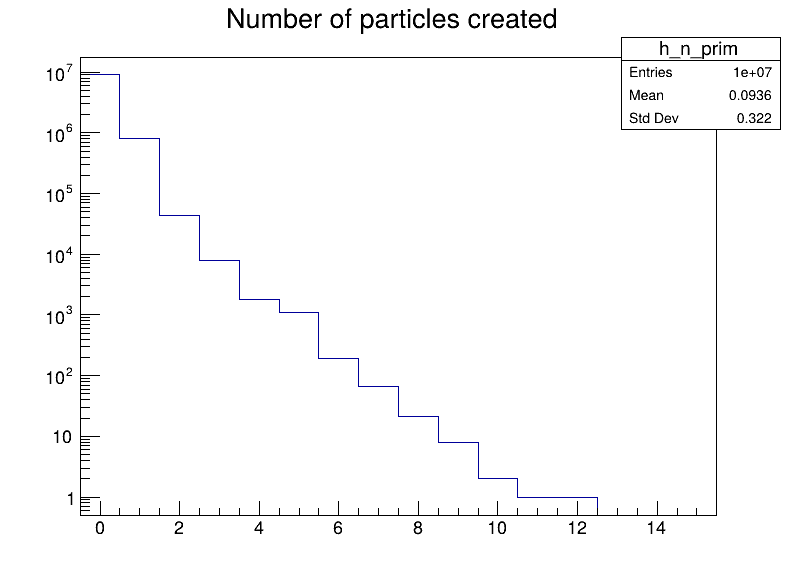

In [8]:
cc = R.TCanvas("cc","cc",800,600)
cc.SetLogy()
h_n_prim.Draw()
cc.Draw()

In [15]:
pr=df_exit.Filter("pdg==11").Display(("event","E","px","py","pz","pdg", "particle", "process"), 30)
pr

Row,event,E,px,py,pz,pdg,particle,process
0,12648,3739.956977,-0.108487,-0.440437,3740.467914,11,e- ma  ,primary d      
1,12649,3739.962403,-0.904767,-1.781174,3740.472834,11,e- ma  ,primary d      
2,12650,3739.953857,0.939755,1.487722,3740.464407,11,e- ma  ,primary d      
3,12651,3737.776703,1.127853,2.797485,3738.286450,11,e- ma  ,primary d      
5,12652,3739.962073,1.883499,-0.803996,3740.472476,11,e- ma  ,primary d      
6,12653,3739.837767,-0.613175,-1.026392,3740.348540,11,e- ma  ,primary d      
7,12654,3739.950803,0.387032,1.036205,3740.461603,11,e- ma  ,primary d      
8,12655,3739.931968,1.632716,0.096933,3740.442575,11,e- ma  ,primary d      
9,12656,3739.950816,-1.545027,1.581586,3740.461127,11,e- ma  ,primary d      
10,12657,3739.964335,-1.689211,-0.522008,3740.474882,11,e- ma  ,primary d      
